<a href="https://colab.research.google.com/github/arvishcdoshi/500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code/blob/main/Arvish_Doshi_Dating%2C_Dining%2C_and_Doomscrolling_The_Algorithms_Behind_Modern_Choice_Pycon2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyCon India - 12 September 2025
## Dating, Dining, and Doomscrolling: The Algorithms Behind Modern Choice - [Proposal Link](https://cfp.in.pycon.org/2025/talk/7SBLGV/)

### [Presentation Link](https://docs.google.com/presentation/d/13OVJXdzxnukREclqA6cgbisVmg_ogArpzJhGPJF2bJI/edit?usp=sharing)





## About the Dataset
MovieLens 100K is a classic recommender dataset created by GroupLens Research in 1998.

It contains 100,000 ratings by 943 users on 1,682 movies.

Number of users: 943
Number of items: 1682
Number of ratings: 100000
Rating distribution:
 rating
4    34174
3    27145
5    21201
2    11370
1     6110
Name: count, dtype: int64


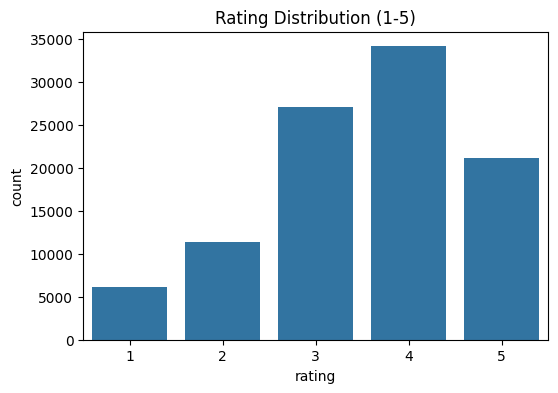

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
cols = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(url, sep='\t', names=cols)

# Quick analysis
print("Number of users:", df['user_id'].nunique())
print("Number of items:", df['item_id'].nunique())
print("Number of ratings:", len(df))
print("Rating distribution:\n", df['rating'].value_counts())

# Visualize rating distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution (1-5)")
plt.show()

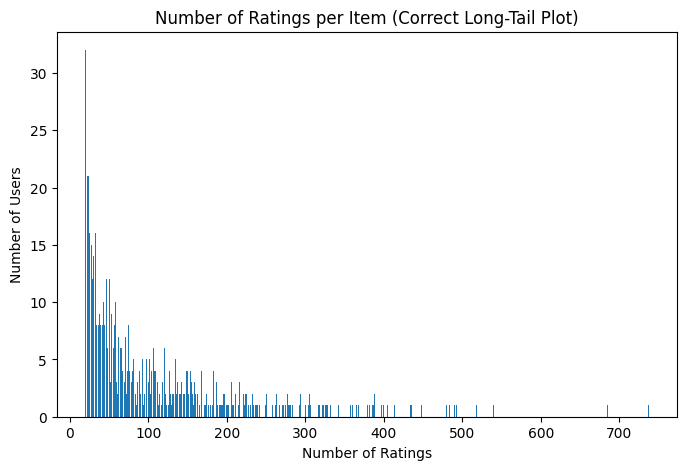

In [ ]:

# Number of ratings per user
item_counts = df['user_id'].value_counts()
freq_counts = item_counts.value_counts().sort_index()  # How many items have N ratings

plt.figure(figsize=(8,5))
plt.bar(freq_counts.index, freq_counts.values)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.title("Number of Ratings per Item (Correct Long-Tail Plot)")
plt.show()

### Observation / Explanation:

Most users have rated only a few items, while a small number of “power users” have rated many items.

This creates a long-tail distribution, typical in recommendation datasets.

Implication: Models must handle data sparsity, since most users have very few interactions.

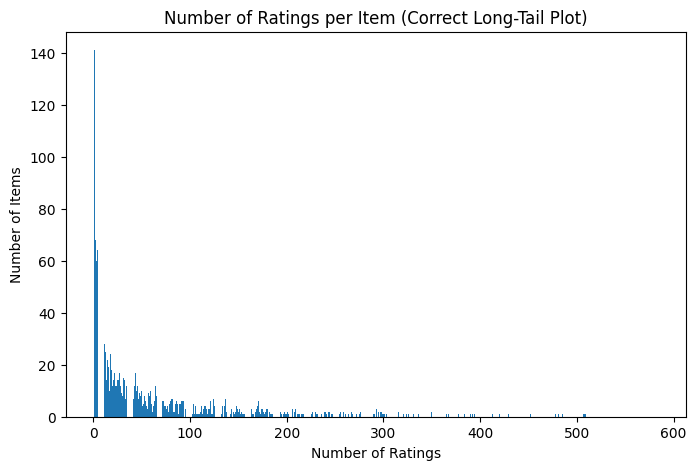

In [ ]:

item_counts = df['item_id'].value_counts()
freq_counts = item_counts.value_counts().sort_index()  # How many items have N ratings

plt.figure(figsize=(8,5))
plt.bar(freq_counts.index, freq_counts.values)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Items")
plt.title("Number of Ratings per Item (Correct Long-Tail Plot)")
plt.show()

### Observation / Explanation:

Some movies (blockbusters) are rated by many users, while most items are rated by very few.

This is another long-tail phenomenon, often called popularity bias.

Implication: Without careful design, models tend to over-recommend popular items, ignoring niche items.

### Sparsity of the Data.


In [ ]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_interactions = len(df)

sparsity = 1 - (n_interactions / (n_users * n_items))
print(f"Number of users: {n_users}")
print(f"Number of items: {n_items}")
print(f"Number of interactions: {n_interactions}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")

Number of users: 943
Number of items: 1682
Number of interactions: 100000
Sparsity: 0.9370 (93.70%)


### Observation / Explanation:

Data is sparse.

## Modeling Discussion

Modeling User-Item Interactions

**Explicit Ratings Prediction:**
- Treat ratings as numeric (regression) or categorical (classification).  
- Captures fine-grained user preferences.  
- Harder to train on sparse datasets; less aligned with top-k recommendations.



**Implicit Feedback Modeling:**

- Focuses on whether a user interacted with an item or not.  
- Can include negative sampling or weighting for non-interacted items.  
- Well-suited for sparse, real-world datasets.  


### Two-Tower Models
- Two-tower architectures are widely used in recommendation systems.  
- They consist of two separate embedding networks: one for users and one for items.  
- Each network maps its input (user ID or item ID) to a latent embedding vector.  
- The similarity between a user and an item is then computed, typically using a dot product or cosine similarity, to estimate the likelihood of interaction.


### Why Negative Sampling is Important
In sparse datasets, most user-item pairs have no observed interaction. Simply training on positive interactions does not teach the model what the user does not like, and embeddings can collapse.  
Negative sampling addresses this by providing contrasting examples: each positive interaction is compared against one or more negative items, which encourages the model to pull the user embedding closer to positive items and push it away from negatives. This process also encourages item-item and user-user structures in the embedding space, meaning similar users or similar items naturally cluster together.

#### Types of Negative Sampling

**Explicit Negative Sampling**

- Negative items are explicitly sampled from the set of non-interacted items, either uniformly or using some heuristics (e.g., popularity-based sampling).  
- Pros: Allows control over the negatives, can focus on "hard negatives" to make the model learn better.  
- Cons: Requires careful sampling; poor negative choice can harm convergence or introduce bias.

**Implicit / In-Batch Negative Sampling**

- All other items in the current training batch are treated as negatives for each positive user-item pair.  
- Pros: Efficient (no extra sampling), naturally scales with batch size, widely used in frameworks like TFRS.  
- Cons: Batch size limits the number of negatives; very small batches may be insufficient for learning strong contrasts.

**Dynamic / Hard Negative Sampling**

- Negatives are selected dynamically based on the current model’s predictions, often choosing items the model thinks are likely positive.
- Pros: Provides challenging contrasts, leading to better embeddings.
- Cons: More computationally expensive, can introduce instability if negatives are too hard early in training.

**Random Negative Sampling**

- Randomly pick items not interacted with by the user.
- Pros: Simple and cheap.
- Cons: Often too easy; the model may not learn fine-grained distinctions.


**Effect on Training and Embeddings**

- Positive vs Negative comparison ensures the embeddings are discriminative, creating meaningful distances in the latent space.
- Encourages user-user similarity: users with similar positive interactions end up with closer embeddings.
- Encourages item-item similarity: items that are interacted with by similar users cluster together.
- The choice of negative sampling strategy affects training stability, convergence speed, and embedding quality.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TwoTowerInBatch(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=16):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)

    def forward(self, user_ids, item_ids):
        u = F.normalize(self.user_emb(user_ids), dim=-1)  # B x D
        i = F.normalize(self.item_emb(item_ids), dim=-1)  # B x D
        return u, i

def in_batch_loss(user_vecs, item_vecs):
    """
    user_vecs: B x D
    item_vecs: B x D
    """
    sim_matrix = user_vecs @ item_vecs.T  # B x B
    targets = torch.arange(user_vecs.size(0), device=user_vecs.device)
    loss = nn.CrossEntropyLoss()(sim_matrix, targets)
    return loss


In [ ]:
TwoTowerInBatch(30,20)

TwoTowerInBatch(
  (user_emb): Embedding(30, 16)
  (item_emb): Embedding(20, 16)
)

In [ ]:
a = TwoTowerInBatch(30,20) (torch.randint(0,30,(10,)),torch.randint(0,20,(10,)))
print(a)
in_batch_loss(*a)

(tensor([[ 0.2013, -0.3798, -0.1591,  0.1107,  0.1089, -0.1487,  0.1813,  0.3037,
         -0.2253, -0.0673, -0.2661,  0.1992, -0.3850, -0.3896,  0.3359, -0.1999],
        [ 0.2504, -0.0582, -0.1768,  0.3172,  0.0586, -0.1344, -0.1563,  0.0211,
         -0.1516, -0.1862,  0.0222,  0.3280, -0.4514, -0.4092,  0.0913, -0.4586],
        [-0.0268,  0.0966,  0.7166, -0.3511,  0.2367, -0.1551, -0.1116, -0.2834,
          0.3880, -0.0764,  0.0390,  0.0688,  0.0452, -0.0219,  0.0752, -0.0974],
        [ 0.1826,  0.2757, -0.0133, -0.4028, -0.0610,  0.5921, -0.2380,  0.2112,
          0.0650, -0.1071, -0.0522,  0.0730, -0.3090, -0.0089, -0.2606, -0.2923],
        [ 0.1170,  0.1439, -0.2030,  0.2190, -0.0458,  0.4509,  0.1326, -0.2824,
         -0.0157,  0.5228,  0.3209, -0.1347, -0.0613, -0.0551,  0.2873,  0.2993],
        [ 0.2323,  0.3057, -0.6572,  0.2680, -0.0975, -0.1354, -0.2126,  0.1486,
          0.1553,  0.1437,  0.1557,  0.2544,  0.3386, -0.0191,  0.0316, -0.0628],
        [-0.1194, -0.

tensor(2.4193, grad_fn=<NllLossBackward0>)

In [ ]:
df_pos = df[df['rating'] >= 4].reset_index(drop=True)

# Remap user/item IDs to contiguous integers
user2id = {uid: i for i, uid in enumerate(df_pos['user_id'].unique())}
item2id = {iid: i for i, iid in enumerate(df_pos['item_id'].unique())}

df_pos['user_id'] = df_pos['user_id'].map(user2id)
df_pos['item_id'] = df_pos['item_id'].map(item2id)

n_users = df_pos['user_id'].nunique()
n_items = df_pos['item_id'].nunique()

# Dataset class
from torch.utils.data import Dataset, DataLoader

class ImplicitDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]  # <-- use iloc for position-based indexing
        return torch.tensor(row['user_id']), torch.tensor(row['item_id'])


In [ ]:
ImplicitDataset(df_pos)[53]

(tensor(30), tensor(50))

In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_pos, test_size=0.2, random_state=42)
train_dataset = ImplicitDataset(train_df)
test_dataset = ImplicitDataset(test_df)

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TwoTowerInBatch(n_users, n_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

epochs = 10

for epoch in tqdm(range(epochs)):
    # ---- Training ----
    model.train()
    total_train_loss = 0
    for user_ids, item_ids in train_loader:
        user_ids, item_ids = user_ids.to(device), item_ids.to(device)
        optimizer.zero_grad()
        u_vecs, i_vecs = model(user_ids, item_ids)
        loss = in_batch_loss(u_vecs, i_vecs)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_loss = 0
    with torch.no_grad():
        for user_ids, item_ids in test_loader:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            u_vecs, i_vecs = model(user_ids, item_ids)
            loss = in_batch_loss(u_vecs, i_vecs)
            total_loss += loss.item()
    average_loss = total_loss / len(test_loader)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {average_loss:.4f}")


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 6.2628 | Test Loss: 6.2538
Epoch 2/10 | Train Loss: 6.2396 | Test Loss: 6.2561
Epoch 3/10 | Train Loss: 6.2176 | Test Loss: 6.2561
Epoch 4/10 | Train Loss: 6.1949 | Test Loss: 6.2528
Epoch 5/10 | Train Loss: 6.1706 | Test Loss: 6.2438
Epoch 6/10 | Train Loss: 6.1442 | Test Loss: 6.2286
Epoch 7/10 | Train Loss: 6.1150 | Test Loss: 6.2064
Epoch 8/10 | Train Loss: 6.0838 | Test Loss: 6.1786
Epoch 9/10 | Train Loss: 6.0526 | Test Loss: 6.1481
Epoch 10/10 | Train Loss: 6.0237 | Test Loss: 6.1187


### There is something subtly wrong catch it.
hints - Better Training-Test Split Strategy for Implicit Feedback

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def recommend_top_k(model, user_id, train_items_set, all_items, k=10, device='cpu'):
    model.eval()
    with torch.no_grad():
        # Compute user embedding
        user_tensor = torch.tensor([user_id]).to(device)
        u_emb = F.normalize(model.user_emb(user_tensor), dim=-1)  # 1 x D

        # Compute all item embeddings
        all_item_tensor = torch.tensor(list(all_items)).to(device)
        i_emb = F.normalize(model.item_emb(all_item_tensor), dim=-1)  # N x D

        # Compute cosine similarity
        scores = (u_emb @ i_emb.T).cpu().numpy().flatten()

        # Exclude items the user already interacted with
        for idx, item in enumerate(all_items):
            if item in train_items_set:
                scores[idx] = -np.inf

        # Get top-K indices
        top_k_idx = np.argsort(-scores)[:k]
        top_k_items = [list(all_items)[i] for i in top_k_idx]

    return top_k_items

user_id = 5
train_items_set = set(train_df[train_df['user_id']==user_id]['item_id'].tolist())
all_items = set(range(n_items))

top_10_recs = recommend_top_k(model, user_id, train_items_set, all_items, k=10, device=device)
print(f"Top-10 recommendations for user {user_id}: {top_10_recs}")

Top-10 recommendations for user 5: [765, 1321, 1434, 405, 782, 634, 1318, 1005, 970, 960]


#### We have done user-item similarity.
1. Can you write code to predict for all users and see how much is our recommendation pool.
1. Can you plot and visualize is user embeddings and item embeddings seperately to see how is embedding positioned.
2. Can you write code to find similar users and similar items.

In [ ]:
from collections import defaultdict

# Build dictionaries for evaluation
train_dict = defaultdict(set)
test_dict = defaultdict(set)

for u, i in zip(train_df['user_id'], train_df['item_id']):
    train_dict[u].add(i)

for u, i in zip(test_df['user_id'], test_df['item_id']):
    test_dict[u].add(i)


In [ ]:
import numpy as np

def recommend_for_user(model, user_id, all_items, train_items, device="cpu", top_k=10):
    model.eval()
    with torch.no_grad():
        u = torch.tensor([user_id]).to(device)
        # score against all items
        items = torch.tensor(list(all_items)).to(device)
        u_vec = F.normalize(model.user_emb(u), dim=-1)  # 1 x D
        i_vecs = F.normalize(model.item_emb(items), dim=-1)  # N x D
        scores = (u_vec @ i_vecs.T).cpu().numpy().flatten()
    ranked_idx = np.argsort(-scores)
    ranked_items = [list(all_items)[i] for i in ranked_idx]
    # filter out training items
    ranked_items = [it for it in ranked_items if it not in train_items]
    return ranked_items[:top_k]


In [ ]:
def precision_recall_at_k(model, train_dict, test_dict, n_items, k=10, device="cpu"):
    precisions, recalls = [], []
    all_items = set(range(n_items))

    for user, test_items in test_dict.items():
        if not test_items:
            continue
        train_items = train_dict[user]
        ranked_items = recommend_for_user(model, user, all_items, train_items, device, top_k=k)

        hits = len(set(ranked_items) & test_items)
        precisions.append(hits / k)
        recalls.append(hits / len(test_items))

    return np.mean(precisions), np.mean(recalls)


In [ ]:
prec, rec = precision_recall_at_k(model, train_dict, test_dict, n_items, k=10, device=device)
print(f"Precision@10: {prec:.4f} | Recall@10: {rec:.4f}")

Precision@10: 0.0333 | Recall@10: 0.0392


### Problem with Offline Evaluation in Retrieval

When we evaluate a retrieval/recommendation model offline (without deploying it), the evaluation depends heavily on the strategy we choose for ranking.

Option 1: Rank against all candidates
We compare the user’s embedding against every item in the catalog.
This gives the most faithful estimate of real-world ranking but can be computationally expensive if the catalog is huge.

Option 2: Rank against a sampled set of negatives
We rank the true positive item against a subset of items (e.g., in-batch negatives, random sampling, or popularity-biased sampling).
This is computationally cheaper, but results depend on the negative sampling strategy → different strategies can change metrics drastically.